# **DATA MODELLING**

## UNSUPERVISED LEARNING - Clustering

Lets look at a very simple example of unsupervised learning.

###1. Load and Explore the data

1.1 Load the penguis dataset from seaborn.

In [1]:
# import

import seaborn as sns
# Load the dataset
df = sns.load_dataset("penguins")


1.2 Look at the raw data.

In [2]:
# Display head of the data
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


1.3 Visualise the data using a [3D scatter plot](https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html).
Select three suitable variables to plot.

Text(0.5, 0, 'body mass (g)')

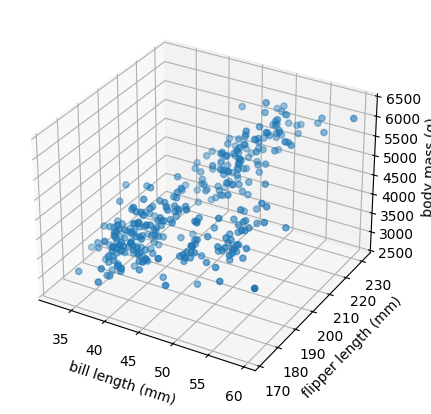

In [12]:
#Import the relevant libraries
import matplotlib.pyplot as plt
import numpy as np

# Visualisation code here

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(projection='3d')
ax.scatter(df['bill_length_mm'],df["flipper_length_mm"],df["body_mass_g"])
ax.set_xlabel("bill length (mm)")
ax.set_ylabel("flipper length (mm)")
ax.set_zlabel("body mass (g)")




###2. Data Processing - part 1

2.1 Identify the catagorical columns (https://medium.com/@fathima.nusra.thameem/how-to-find-categorical-columns-in-your-pandas-dataframe-e7553feef62e) and put them in a list.

Hint: look for 'catagory' AND 'object'.

In [22]:
catagorical_col = df.select_dtypes(include=['object','category'])
catagorical_col.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   species  344 non-null    str  
 1   island   344 non-null    str  
 2   sex      333 non-null    str  
dtypes: str(3)
memory usage: 8.2 KB


C:\Users\Senzwa4\AppData\Local\Temp\ipykernel_36684\4180450780.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catagorical_col = df.select_dtypes(include=['object','category'])


2.2 Encode categorical variables 'island', 'species' and 'sex' using [LabelEncoder](https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/).

In [27]:
# Encode categorical variables.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['species'].unique())
df['species']=le.transform(df['species'])

le = LabelEncoder()
le.fit(df['island'].unique())
df['island']=le.transform(df['island'])

le = LabelEncoder()
le.fit(df['sex'].unique())
df['sex']=le.transform(df['sex'])

###3. Exploratory Data Analysis
Here we have a simple dataset, but what would you do if it was more complicated? EDA!

Let's use pairplots and 3D scatter plots to do some EDA...

3.1 Lets start with the seaborn [Pair plot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).

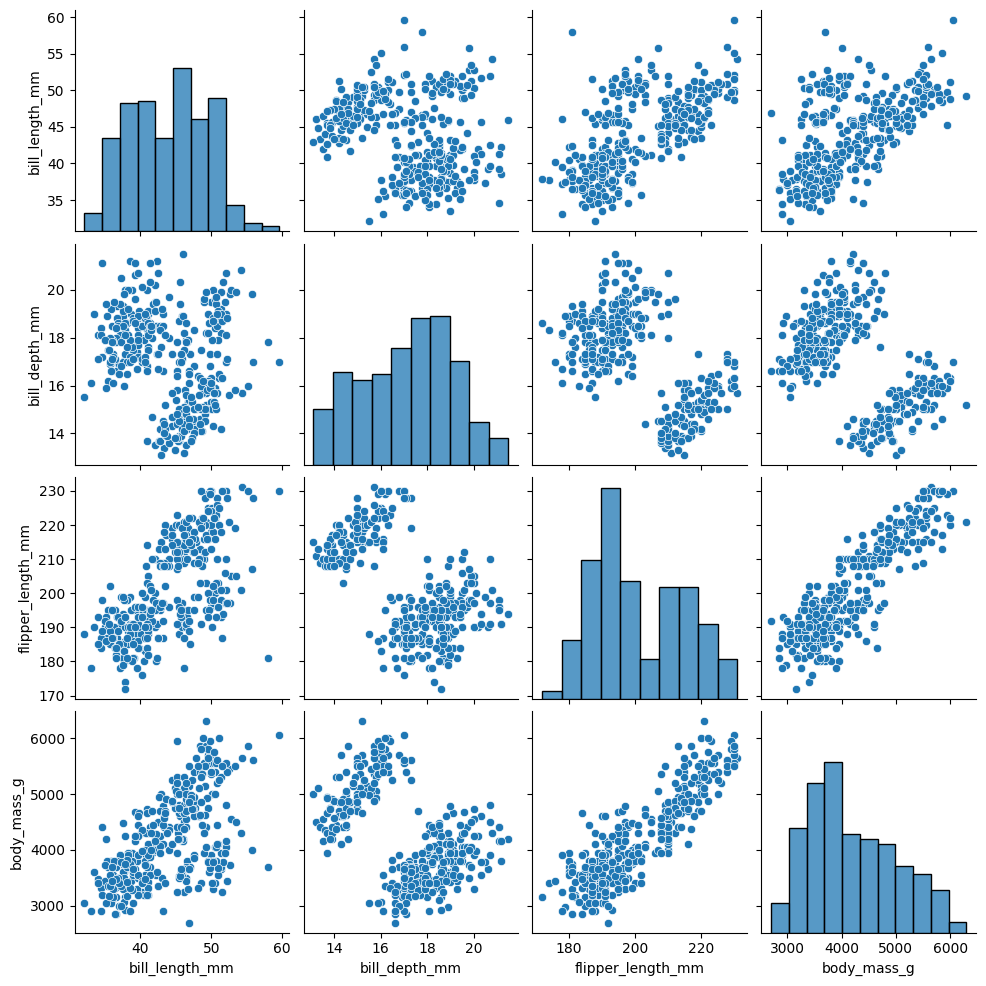

In [31]:
sns.pairplot(df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]])

3.2 Let's recreate the earlier [3D scatter plot](https://machinelearningmastery.com/data-visualization-in-python-with-matplotlib-seaborn-and-bokeh/) but add the species as the hue (c).

Text(0.5, 0, 'body mass (g)')

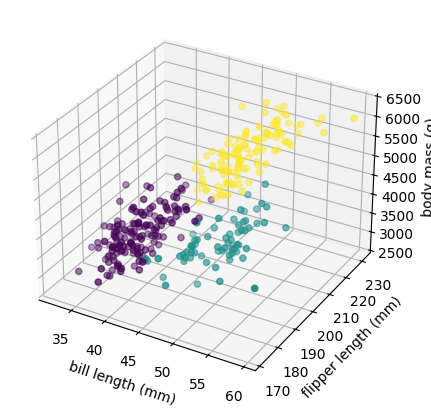

In [30]:
fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(projection='3d')
ax.scatter(df['bill_length_mm'],df["flipper_length_mm"],df["body_mass_g"],c=df['species'])
ax.set_xlabel("bill length (mm)")
ax.set_ylabel("flipper length (mm)")
ax.set_zlabel("body mass (g)")

### 4.  Data Processing - part 2

4.1 Remove the catagorical columns - It makes no sense to do clustering if we include the catagorical data. Let's see if we will still have the expected 3 clusters without it.

4.2 Remove the records with missing nans,

4.3 randomise the data and

4.4 convert to array.

In [35]:
df.isnull().sum()


species    0
island     0
sex        0
dtype: int64

In [36]:
df.dropna(axis="columns", how="any", inplace=True)

### 5. Clustering
Clearly clustering would be an ideal solution, so lets try the K=means method.

Look at the documentation for the **python library "sklearn kmeans clustering"** for what the algorithm requires.

From the documentation the only input the algorithm requires is the number of clusters (k).
It should be noted that while a random state is not required, it would be a good idea to set it for reproducablilty, we can just choose 0.

5.1 Determine number of clusters.

The way to determine the optimal number of clusters is to use the **elbow method**. More information on how to impliment this method can be obtained by looking at the documentation for the elbow method in the python library yellowbrick by searching something like **"yellowbrick elbow method"**.

Follow the instructions and impliment the elbow method to determine the optimal number of clusters.

Determine where the elbow 'bends' (blue line) to the largest degree or the most obviously.

NOTE: if the data in not suitable for clustering, the method wont work well or even at all.

5.2 Run the model.

Next, we implement the kmeans clusterning using the instructions in the sklearn kmeans documentation and fit the model to the data. (Because it's unsupervised ther is no train/test split or target varaible).

5.3 Display the predicted cluster centers.

Lest see where the identified cluster centers are located using a print statement.

5.4 Visualising cluster centers on data.

Finally lets visualise the previous 3D plot, but now also include the cluster centers on the plot. (**HINT**: use a scatterplot with markers and count in what columns the features that you are plotting are. E.g body_mass was in column 5.)